# Predicting App Market Success Using Machine Learning

The mobile application market is highly competitive. Thousands of apps are released daily, but only a small fraction achieve widespread adoption.

This project analyzes the Google Play Store ecosystem and builds a machine learning model to predict whether an app will achieve market success.

Success is defined as apps exceeding 1 million installs.

In [119]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [88]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

In [89]:
from google.colab import files
uploaded = files.upload()

Saving googleplaystore.csv to googleplaystore (1).csv


In [90]:
import pandas as pd

df = pd.read_csv("googleplaystore.csv")

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [91]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [92]:
df[df["Installs"] == "Free"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [94]:
df = df[df["Installs"] != "Free"]

In [95]:
df["Installs"] = df["Installs"].str.replace("+", "", regex=False)
df["Installs"] = df["Installs"].str.replace(",", "", regex=False)

df["Installs"] = df["Installs"].astype(int)

In [96]:
df["Success"] = np.where(df["Installs"] > 1000000,1,0)

In [97]:
df["Price"] = df["Price"].str.replace("$","")
df["Price"] = df["Price"].astype(float)

In [98]:
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [99]:
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

In [100]:
df["Type"] = df["Type"].fillna("Free")

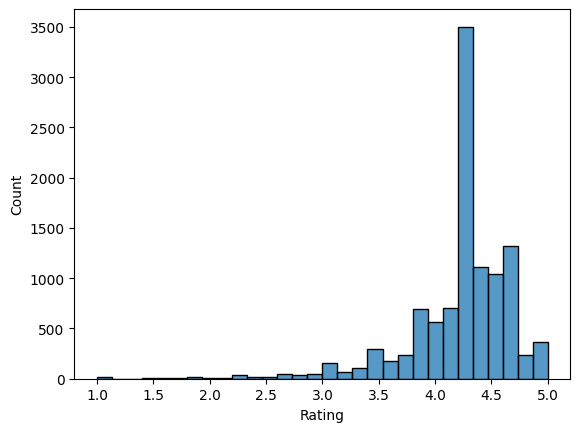

<Axes: xlabel='Category', ylabel='Installs'>

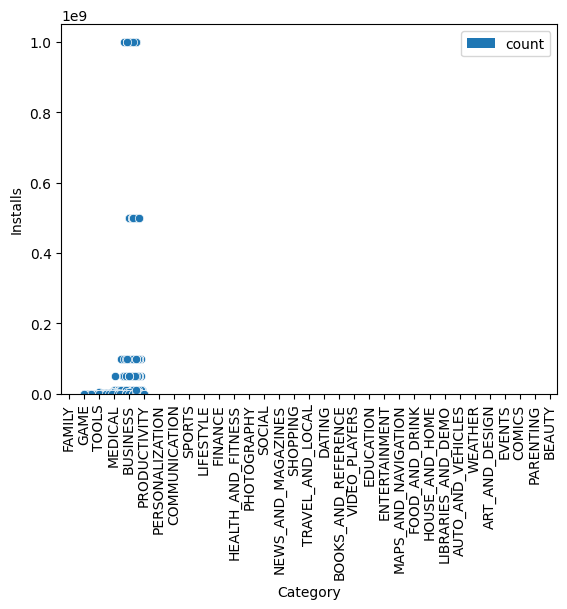

In [101]:
sns.histplot(df["Rating"], bins=30)
plt.show()
df["Category"].value_counts().plot(kind="bar")
sns.scatterplot(x="Rating",y="Installs",data=df)

<Axes: >

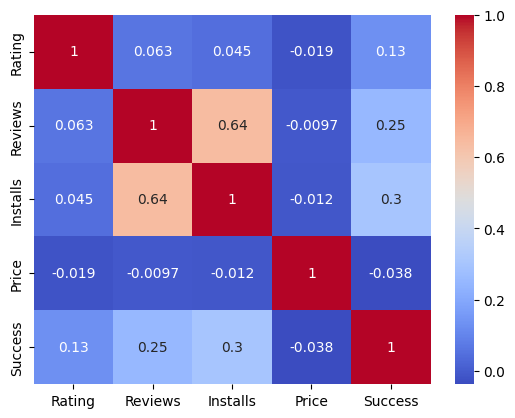

In [102]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr,annot=True,cmap="coolwarm")

In [103]:
le = LabelEncoder()

df["Category"] = le.fit_transform(df["Category"])
df["Type"] = le.fit_transform(df["Type"])

In [104]:
X = df[["Rating","Reviews","Price","Category","Type"]]
y = df["Success"]

In [105]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [137]:
X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [138]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

## Determining Optimal Clusters using the Elbow Method

Before applying K-Means clustering, it is necessary to determine the optimal number of clusters.

The Elbow Method evaluates the Within-Cluster Sum of Squares (WCSS) for different numbers of clusters.

The point where the reduction in WCSS begins to slow significantly forms an "elbow", indicating the optimal number of clusters.

In [106]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


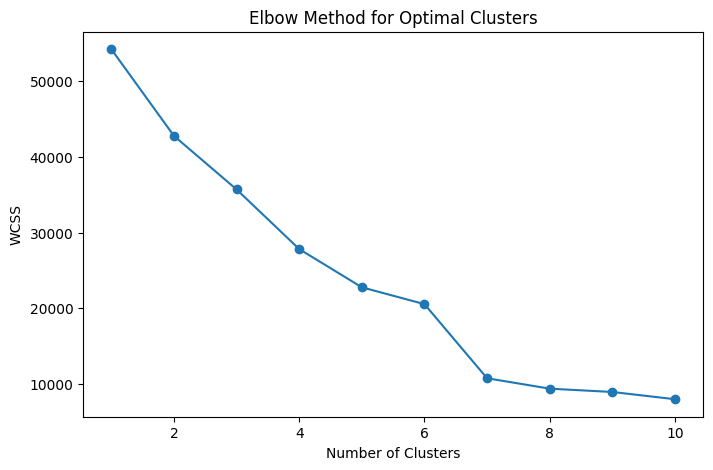

In [107]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Category"] = le.fit_transform(df["Category"])
df["Type"] = le.fit_transform(df["Type"])
X = df[["Rating","Reviews","Price","Category","Type"]]

y = df["Success"]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

The graph plots the number of clusters against the WCSS (Within Cluster Sum of Squares).

The curve typically decreases rapidly and then begins to flatten.

The point where the curve bends (forming an elbow) represents the optimal number of clusters.

In this project, the elbow occurs around k = 3, which is why K-Means clustering is performed with three clusters.

In [117]:
df["Reviews"] = df["Reviews"].fillna(df["Reviews"].median())

In [123]:
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")
df["Reviews"] = df["Reviews"].fillna(df["Reviews"].median())

In [130]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df["App_Cluster"] = kmeans.fit_predict(X_scaled)

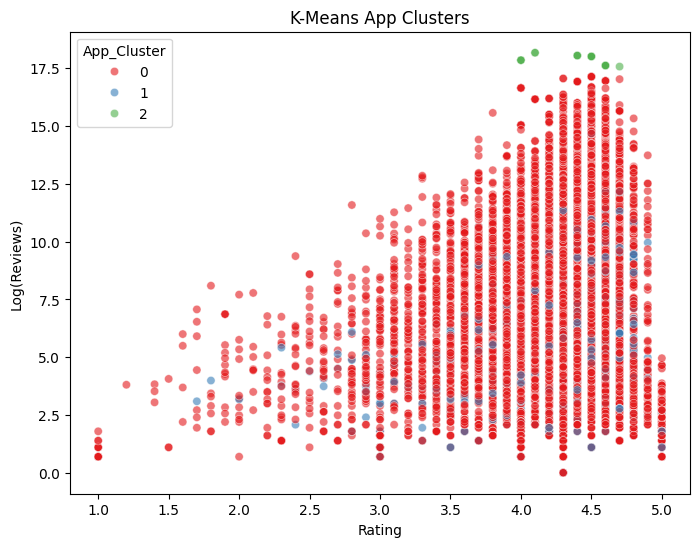

In [131]:
import numpy as np

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Rating"],
    y=np.log1p(df["Reviews"]),
    hue=df["App_Cluster"],
    palette="Set1",
    alpha=0.6
)

plt.xlabel("Rating")
plt.ylabel("Log(Reviews)")
plt.title("K-Means App Clusters")

plt.show()

Cluster 0 → Apps with lower reviews

Cluster 1 → Apps with moderate engagement

Cluster 2 → Highly reviewed apps

In [112]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:,0]
df["PCA2"] = X_pca[:,1]

In [135]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
df["PCA1"] = X_pca[:,0]
df["PCA2"] = X_pca[:,1]


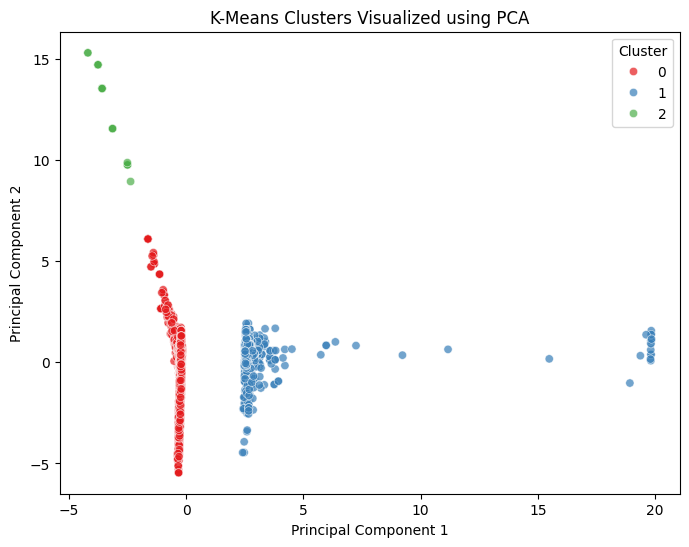

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["PCA1"],
    y=df["PCA2"],
    hue=df["App_Cluster"],
    palette="Set1",
    alpha=0.7
)

plt.title("K-Means Clusters Visualized using PCA")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

Cluster 0 → similar app characteristics

Cluster 1 → another app segment

Cluster 2 → different market group

---



In [134]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df["App_Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.6150138585260645


Text(50.722222222222214, 0.5, 'Actual')

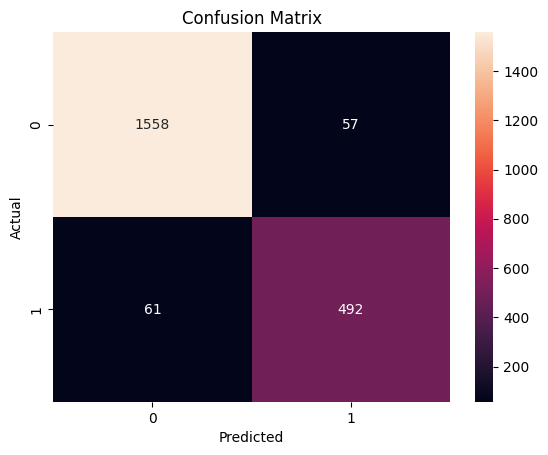

In [129]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

Text(0.5, 1.0, 'ROC Curve')

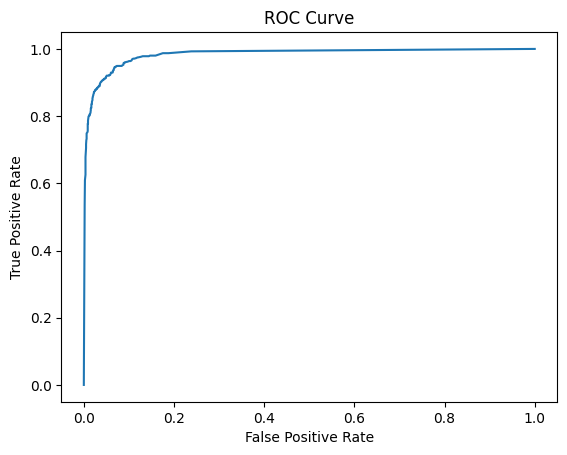

In [125]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr,tpr,thresholds = roc_curve(y_test,y_prob)

plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

In [126]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy: 0.9455719557195572
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1615
           1       0.90      0.89      0.89       553

    accuracy                           0.95      2168
   macro avg       0.93      0.93      0.93      2168
weighted avg       0.95      0.95      0.95      2168



In [127]:
param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,20]
}

grid = GridSearchCV(RandomForestClassifier(),param_grid,cv=5)

grid.fit(X_train,y_train)

grid.best_params_

{'max_depth': 20, 'n_estimators': 300}

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Rating'),
  Text(1, 0, 'Reviews'),
  Text(2, 0, 'Price'),
  Text(3, 0, 'Category'),
  Text(4, 0, 'Type')])

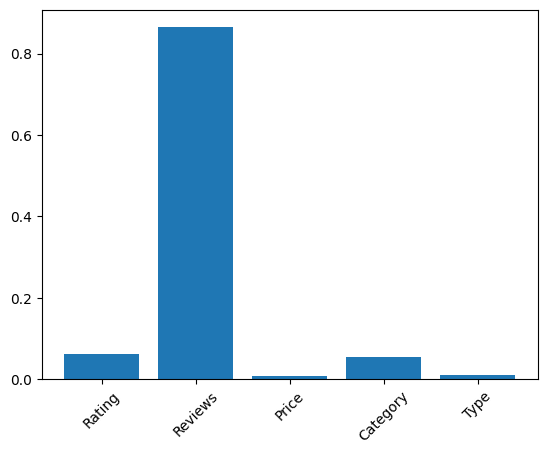

In [128]:
importance = rf.feature_importances_

plt.bar(X.columns,importance)
plt.xticks(rotation=45)

Key findings:

• Higher ratings strongly correlate with success

• Apps with large review volumes are more likely to succeed

• Free apps tend to have higher install counts

• Category also influences market success